# How to count objects

```python
H, W = image.shape[:2]
counted = np.zeros_like(image)
# 카운트
cnt = 0
for h in range(H):
    for w in range(W):
        pixel = image[h,w]
        # 배경이 아니고 카운트 한적 없는 픽셀이면
        # 카운트 한적 없는 픽셀을 검사해야 하는 이유 : 새로운 물체가 검사되기 위해서
        # pixel 의 주위 픽셀이 물체라고 감지되면 이는 pixel 의 카운트에 종속되므로 중복되면 안됨
        if (pixel is not background) and (not counted):
            # 새로운 물체 발견되었으니 cnt += 1
            cnt += 1
            # 스택을 하나 만들고 스택에 pixel index 저장
            Generate a stack and insert the pixel idx [h,w] into the stack
            # 스택이 empty 될 동안 무한루프
            while the stack is not empty:
                # 스택에서 pixel 하나 pop 
                Pop one pixel idx up from the stack
                # 탐색된 것으로 mark
                mark as counted
                # 주위 8 방향 픽셀 체크
                for pixel in the neighbor pixels:
                    # 그 픽셀이 바운드 안에 있고 배경이 아니고 이전에 탐색 된 적도 없으면
                    if (pixel is in bound) and (pixel is not background) and (not counted):
                        # 스택에 해당 픽셀 넣음
                        Insert this pixel to the `stack`
print(cnt) 

# counted 에 1이 체크된것이 다 물체
print(counted)
```

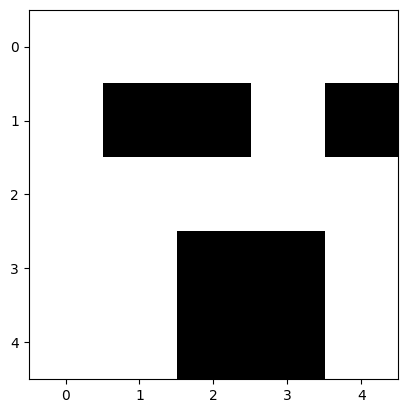

In [12]:
import numpy as np
import matplotlib.pyplot as plt

image = np.full((5,5), 255, dtype = 'uint8')

image[1,1:3] = 0
image[1, 4] = 0
image[3:5, 2:4] = 0

plt.imshow(image, cmap='gray')
plt.show()

In [14]:


H, W = image.shape[:2]
counted = np.zeros((H, W), dtype=np.uint8)
cnt = 0

def is_in_bound(pixel):
    y, x = pixel
    return 0 <= y < H and 0 <= x < W

def is_bg(pixel):
    y, x = pixel
    return image[y, x] == 255

def is_counted(pixel):
    y, x = pixel
    return counted[y, x] == 1

for h in range(H):
    for w in range(W):
        pixel = image[h, w]

        if pixel != 255 and counted[h, w] == 0:
            cnt += 1
            stack = [(h, w)]

            while len(stack) != 0:
                y, x = stack.pop()
                counted[y, x] = 1

                for ny in range(y - 1, y + 2):
                    for nx in range(x - 1, x + 2):
                        neighbor = (ny, nx)

                        if is_in_bound(neighbor) and not is_bg(neighbor) and not is_counted(neighbor):
                            stack.append(neighbor)
print(cnt) 

# counted 에 1이 체크된것이 다 물체
print(counted)

3
[[0 0 0 0 0]
 [0 1 1 0 1]
 [0 0 0 0 0]
 [0 0 1 1 0]
 [0 0 1 1 0]]


In [ ]:
s = [(1,2),(2,2)]
a = s.pop()
print(len(s))
print(a)

h, w = a

print(h, w)